In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df = pd.read_csv("F:\Jupyter Projects\Phitron AL ML\Dataset\insurance.csv")
df

<>:1: SyntaxWarning: invalid escape sequence '\J'
<>:1: SyntaxWarning: invalid escape sequence '\J'
C:\Users\HP\AppData\Local\Temp\ipykernel_16648\2535186054.py:1: SyntaxWarning: invalid escape sequence '\J'
  df = pd.read_csv("F:\Jupyter Projects\Phitron AL ML\Dataset\insurance.csv")


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [35]:
len(df)

1338

In [36]:
age = np.array(df['age'])

len(age)

1338

In [37]:
charges = np.array(df['charges'])
len(charges)

1338

In [38]:
age = (age - age.min()) / (age.max() - age.min())
charges = (charges - charges.min()) / (charges.max() - charges.min())

<Axes: >

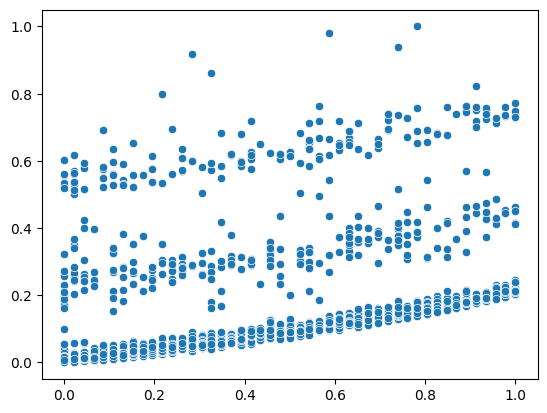

In [39]:
sns.scatterplot(x=age, y=charges)

Iteration 0: Cost 0.07300226902695583, w: 0.0021407992816710898, b: 0.0038783172373972183
Iteration 10: Cost 0.05810548677326499, w: 0.021049920697123983, b: 0.03768631572737936
Iteration 20: Cost 0.04904119285622486, w: 0.03612638994464714, b: 0.06387272382766389
Iteration 30: Cost 0.043521427131275194, w: 0.048210147232406964, b: 0.08412043712130604
Iteration 40: Cost 0.040155878486996505, w: 0.057956023229384826, b: 0.09974127685182123
Iteration 50: Cost 0.038099700927760695, w: 0.06587454993330501, b: 0.11175780309058886
Iteration 60: Cost 0.03683950572781258, w: 0.0723637737819465, b: 0.12096709014198687
Iteration 70: Cost 0.036063317561879804, w: 0.07773405478748065, b: 0.12799044106104598
Iteration 80: Cost 0.035581552128114285, w: 0.0822273980997721, b: 0.13331214135715674
Iteration 90: Cost 0.03527899745613692, w: 0.08603252346081824, b: 0.1373096684688163
Iteration 100: Cost 0.0350856348932465, w: 0.08929661223829943, b: 0.1402772407979552
Iteration 110: Cost 0.03495890819672

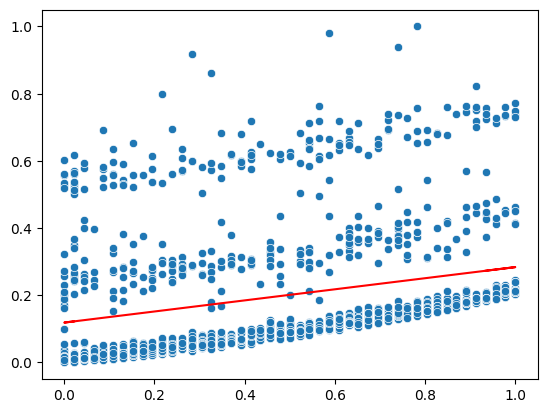

In [41]:
def compute_prediction(age, w, b):
    return w * age + b

def compute_cost(charges, predicted_charges):
    n = len(charges)

    return (1 / n) * np.sum((charges - predicted_charges) ** 2)

def compute_gradient(age, charges, w, b):
    n = len(charges)

    dj_dw = 0.0
    dj_db = 0.0

    for i in range(n):
        prediction = compute_prediction(age[i], w, b)
        error = prediction - charges[i]

        dj_dw += (error * age[i])
        dj_db += error

    dj_dw = (dj_dw * 2) / n
    dj_db = (dj_db * 2) / n

    return dj_dw, dj_db

def gradient_descent(age, charges, w_in, b_in, num_iters, alpha):
    w = w_in
    b = b_in

    cost_hist = []

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(age, charges, w, b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        cost = compute_cost(charges, compute_prediction(age, w, b))
        cost_hist.append(cost)

        if i % 10 == 0:
            print(f"Iteration {i}: Cost {cost}, w: {w}, b: {b}")
        
    return w, b, cost_hist

pred = compute_prediction(age, w=0.16501, b=0.118757)
cost = compute_cost(charges, pred)
sns.scatterplot(x=age, y=charges)
plt.plot(age, pred, color='red')
w, b, cost_hist = gradient_descent(age, charges, w_in=0.0, b_in=0.0, num_iters=1000, alpha=0.01)

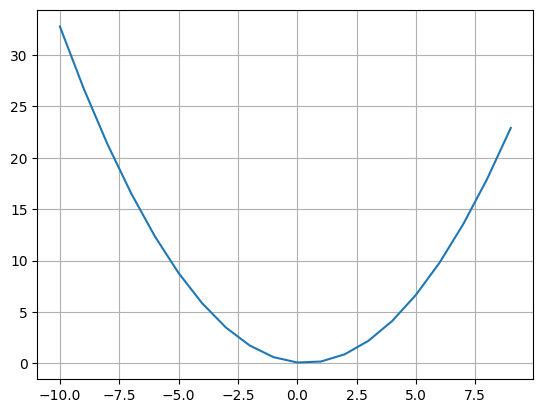

In [43]:
w = []
cost = []

for i in range(-10, 10):
    cost.append(compute_cost(compute_prediction(age, i, b = 0), charges))
    w.append(i)

plt.plot(w, cost)
plt.grid()